<a href="https://colab.research.google.com/github/Kownlage/ML/blob/main/Assignment_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Probability, Linear Algebra, & Computational Programming

Maiko Atsumi
Netid: ma277295

*Names of students you worked with on this assignment*: none
Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus on Canvas for additional information.

Instructions for all assignments can be found [here](https://github.com/kylebradbury/ids705_sp2022/blob/master/assignments/_Assignment%20Instructions.ipynb), and is also linked to from the [course syllabus](https://kylebradbury.github.io/ids705_sp2022/index.html).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

#  Learning Objectives
The purpose of this assignment is to provide a refresher on fundamental concepts that we will use throughout this course, and provide an opportunity to develop skills in any of the related skills that may be unfamiliar to you. Through the course of completing this assignment, you will...
- Refresh you knowledge of probability theory including properties of random variables, probability density functions,  cumulative distribution functions, and key statistics such as mean and variance.
- Revisit common linear algebra and matrix operations and concepts such as matrix multiplication, inner and outer products, inverses, the Hadamard (element-wise) product, eigenvalues and eigenvectors, orthogonality, and symmetry.
- Practice numerical programming, core to machine learning, by loading and filtering data, plotting data, vectorizing operations, profiling code speed, and debugging and optimizing performance. You will also practice computing probabilities based on simulation.
- Develop or refresh your knowledge of Git version control, which will be a core tool used in the final project of this course
- Apply your skills altogether through an exploratory data analysis to practice data cleaning, data manipulation, interpretation, and communication

We will build on these concepts throughout the course, so use this assignment as a catalyst to deepen your knowledge and seek help with anything that is unfamiliar.

Just know... this is supposed to be a hard assignment!  Try your best and allow for enough time to finish.

# Probability and Statistics Theory

*Note: for all assignments, write out all equations and math using markdown and [LaTeX](https://tobi.oetiker.ch/lshort/lshort.pdf). For this assignment show ALL math work*

## 1
**[3 points]**  
Let $f(x) = \begin{cases}
                0           & x < 0  \\
                \alpha x^2  & 0 \leq x \leq 2 \\
                0           & 2 < x
            \end{cases}$
            
For what value of $\alpha$ is $f(x)$ a valid probability density function?

**Answer**

For a valid probability density function $f(x)$, the total integral over all space must equal $1$:

$$\int_{-\infty}^{\infty} f(x) \, dx = 1$$

Since the function $f(x)$ is defined as $0$ outside the interval $[0, 2]$, we integrate only over that range:

$$\int_{0}^{2} \alpha x^2 \, dx = 1$$

Evaluating the definite integral:$$\alpha \left[ \frac{1}{3}x^3 \right]_{0}^{2} = 1$$$$\frac{8}{3}\alpha = 1$$Solving for $\alpha$:$$\alpha = \frac{3}{8} \quad (\text0.375)$$


## 2
**[3 points]** What is the cumulative distribution function (CDF) that corresponds to the following probability distribution function? Please state the value of the CDF for all possible values of $x$.

$f(x) = \begin{cases}
    \frac{1}{3} & 0 < x < 3 \\
    0           & \text{otherwise}
    \end{cases}$

**Answer**

The definition of the CDF is that $F(x)$ represents the probability that the random variable $X$ takes a value less than or equal to $x$, expressed mathematically as $F(x) = P(X \le x)$.

 It is calculated as the integral of the probability density function $f(t)$ from $-\infty$ to $x$:
$$F(x) = \int_{-\infty}^{x} f(t) \, dt$$

Depending on the value of $x$, we evaluate this across three intervals:

1. For $x \le 0$:
$$F(x) = \int_{-\infty}^{x} 0 \, dt = 0$$

2. For $0 < x < 3$:
$$F(x) = \int_{-\infty}^{0} 0 \, dt + \int_{0}^{x} \frac{1}{3} \, dt = 0 + \left[ \frac{1}{3}t \right]_{0}^{x} = \frac{x}{3}$$

3. For $3 \le x$:
$$F(x) = \int_{-\infty}^{0} 0 \, dt + \int_{0}^{3} \frac{1}{3} \, dt + \int_{3}^{x} 0 \, dt = 1$$

Therefore, the CDF for all possible values of $x$ is:

$$F(x) = \begin{cases} 0 & x \le 0 \\ \frac{x}{3} & 0 < x < 3 \\ 1 & 3 \le x \end{cases}$$

## 3
**[6 points]** For the probability distribution function for the random variable $X$,

$f(x) = \begin{cases}
    \frac{1}{3} & 0 < x < 3 \\
    0           & \text{otherwise}
    \end{cases}$
    
what is the (a) expected value and (b) variance of $X$. *Show all work*.

**Answer**

(a) Expected value of $X$:The expected value $E[X]$ is calculated by integrating $x \cdot f(x)$ over all space:
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx = \int_{0}^{3} x \cdot \frac{1}{3} \, dx  = \frac{3}{2} \quad (\text 1.5)$$

(b) Variance of $X$:The variance is given by $\text{Var}(X) = E[X^2] - (E[X])^2$.

First, we find $E[X^2]$:
$$E[X^2] = \int_{-\infty}^{\infty} x^2 \cdot f(x) \, dx = \int_{0}^{3} x^2 \cdot \frac{1}{3} \, dx = 3$$

Now, substitute $E[X^2]$ and $E[X]$ into the variance formula:$$\text{Var}(X) = 3 - \left(\frac{3}{2}\right)^2 = 3 - \frac{9}{4} = \frac{3}{4} \quad (\text 0.75)$$

## 4
**[6 points]** Consider the following table of data that provides the values of a discrete data vector $\mathbf{x}$ of samples from the random variable $X$, where each entry in $\mathbf{x}$ is given as $x_i$.

*Table 1. Dataset N=5 observations*

|        | $x_0$ | $x_1$ | $x_2$ | $x_3$ | $x_4$ |
|------  |-------|-------|-------|-------|-------|
|$\textbf{x}$| 2     | 3     | 10    | -1    | -1    |

What is the (a) mean and (b) variance of the data?

*Show all work. Your answer should include the definition of mean and variance in the context of discrete data. In this case, use the sample variance since the sample size is quite small*

**ANSWER**

(a) Mean of the dataThe sample mean $\bar{x}$ for a discrete dataset is the sum of all observations divided by the total number of observations $N$.

$$\bar{x} = \frac{1}{N} \sum_{i=0}^{N-1} x_i$$

Substituting the given values ($N=5$):
$$\bar{x} = \frac{2 + 3 + 10 + (-1) + (-1)}{5} = \frac{13}{5} (2.6)$$

(b) Variance of the dataAs instructed, because the sample size is small, we must use the sample variance $s^2$ (which divides by $N-1$ to account for Bessel's correction). The sample variance is defined as the sum of squared differences between each observation and the sample mean, divided by $N-1$.

$$s^2 = \frac{1}{N-1} \sum_{i=0}^{N-1} (x_i - \bar{x})^2$$

Substitute the values and the calculated mean ($\bar{x} = 2.6$):

$$s^2 = \frac{1}{5-1} \left[ (2 - 2.6)^2 + (3 - 2.6)^2 + (10 - 2.6)^2 + (-1 - 2.6)^2 + (-1 - 2.6)^2 \right] = \frac{1}{4} \left[ (-0.6)^2 + (0.4)^2 + (7.4)^2 + (-3.6)^2 + (-3.6)^2 \right]= \frac{1}{4} [0.36 + 0.16 + 54.76 + 12.96 + 12.96]= \frac{81.2}{4}( 20.3)$$

# Linear Algebra

## 5
**[14 points]** **Matrix manipulations and multiplication**. Machine learning involves working with many matrices, so this exercise will provide you with the opportunity to practice those skills.

Let
$\mathbf{A} =  \begin{bmatrix}
1 & 2 & 3 \\
2 & 4 & 5 \\
3 & 5 & 6
\end{bmatrix}$, $\mathbf{b} =  \begin{bmatrix}
-1  \\
3  \\
8  
\end{bmatrix}$, $\mathbf{c} =  \begin{bmatrix}
4  \\
-3  \\
6  
\end{bmatrix}$, and $\mathbf{I} =  \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}$

Compute the following (using Python) or indicate that it cannot be computed. Refer to numpy's tools for handling matrices.

1. $\mathbf{A}\mathbf{A}$
2. $\mathbf{A}\mathbf{A}^T$
3. $\mathbf{A}\mathbf{b}$
4. $\mathbf{A}\mathbf{b}^T$
5. $\mathbf{b}\mathbf{A}$
6. $\mathbf{b}^T\mathbf{A}$
7. $\mathbf{b}\mathbf{b}$
8. $\mathbf{b}^T\mathbf{b}$
9. $\mathbf{b}\mathbf{b}^T$
10. $\mathbf{b} + \mathbf{c}^T$
11. $\mathbf{b}^T\mathbf{b}^T$
12. $\mathbf{A}^{-1}\mathbf{b}$
13. $\mathbf{A}\circ\mathbf{A}$
14. $\mathbf{b}\circ\mathbf{c}$

*Note: The element-wise (or Hadamard) product is the product of each element in one matrix with the corresponding element in another matrix, and is represented by the symbol "$\circ$".*

In [57]:
import numpy as np

A =np.array([[1,2,3],[2,4,5],[3,5,6]])
b =np.array([[-1],[3],[8]])
c=np.array([[4],[-3],[6]])
I=np.eye(3)

print("Answer")
print("1. \n", A@A)
print("2. \n", A@A.T)
print("3. \n", A@b)
print("4. \n", "Cannot be computed (Dimension mismatch)")
print("5. \n", "Cannot be computed (Dimension mismatch)")
print("6. \n", b.T@A)
print("7. \n", "Cannot be computed (Dimension mismatch)")
print("8. \n", b.T@b)
print("9. \n", b@b.T)
print("10. \n", "Cannot be computed (Dimension mismatch)")
print("11. \n", "Cannot be computed (Dimension mismatch)")
print("12. \n", np.linalg.inv(A)@b)
print("13. \n", np.multiply(A,A))
print("14. \n", np.multiply(b,c))


Answer
1. 
 [[14 25 31]
 [25 45 56]
 [31 56 70]]
2. 
 [[14 25 31]
 [25 45 56]
 [31 56 70]]
3. 
 [[29]
 [50]
 [60]]
4. 
 Cannot be computed (Dimension mismatch)
5. 
 Cannot be computed (Dimension mismatch)
6. 
 [[29 50 60]]
7. 
 Cannot be computed (Dimension mismatch)
8. 
 [[74]]
9. 
 [[ 1 -3 -8]
 [-3  9 24]
 [-8 24 64]]
10. 
 Cannot be computed (Dimension mismatch)
11. 
 Cannot be computed (Dimension mismatch)
12. 
 [[ 6.]
 [ 4.]
 [-5.]]
13. 
 [[ 1  4  9]
 [ 4 16 25]
 [ 9 25 36]]
14. 
 [[-4]
 [-9]
 [48]]


## 6
**[8 points]** **Eigenvectors and eigenvalues**. Eigenvectors and eigenvalues are useful for some machine learning algorithms, but the concepts take time to solidly grasp. They are used extensively in machine learning and in this course we will encounter them in relation to Principal Components Analysis (PCA), clustering algorithms, For an intuitive review of these concepts, explore this [interactive website at Setosa.io](http://setosa.io/ev/eigenvectors-and-eigenvalues/). Also, the series of linear algebra videos by Grant Sanderson of 3Brown1Blue are excellent and can be viewed on youtube [here](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab). For these questions, numpy may once again be helpful.

1. Calculate the eigenvalues and corresponding eigenvectors of matrix $\mathbf{A}$ above, from the last question.
2. Choose one of the eigenvector/eigenvalue pairs, $\mathbf{v}$ and $\lambda$, and show that $\mathbf{A} \mathbf{v} = \lambda \mathbf{v}$. This relationship extends to higher orders: $\mathbf{A} \mathbf{A} \mathbf{v} = \lambda^2 \mathbf{v}$
3. Show that the eigenvectors are orthogonal to one another (e.g. their inner product is zero). This is true for eigenvectors from real, symmetric matrices. In three dimensions or less, this means that the eigenvectors are perpendicular to each other. Typically we use the orthogonal basis of our standard x, y, and z, Cartesian coordinates, which allows us, if we combine them linearly, to represent any point in a 3D space. But any three orthogonal vectors can do the same. We will see this property is used in PCA to identify the dimensions of greatest variation in our data when we discuss dimensionality reduction.

**ANSWER**

**1. Calculate eigenvalues and eigenvectors**

To find the eigenvalues $\lambda$ and corresponding eigenvectors $v$ for the matrix $A$, we solve the characteristic equation $\det(A - \lambda I) = 0$.

**2. Show $Av = \lambda v$**

By definition, multiplying the matrix $A$ by an eigenvector $v$ only scales the vector by its corresponding eigenvalue $\lambda$, without changing its direction.
We will verify this property using the first eigenvalue $\lambda_1$ and its corresponding eigenvector $v_1$ by showing that:
$$A v_1 = \lambda_1 v_1$$

**3. Show that eigenvectors are orthogonal**

Matrix $A$ is a real, symmetric matrix ($A = A^T$). A fundamental property of real symmetric matrices is that their eigenvectors are orthogonal to one another.
We can prove this by showing that the inner (dot) product of any two distinct eigenvectors is zero (allowing for infinitesimal floating-point errors):
$$v_1 \cdot v_2 = 0, \quad v_2 \cdot v_3 = 0, \quad v_1 \cdot v_3 = 0$$
```



In [58]:
import numpy as np

A = np.array([[1, 2, 3],
              [2, 4, 5],
              [3, 5, 6]])

# 1. Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)
print("1. Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

# 2. Show Av = lambda * v
lambda_1 = eigenvalues[0]
v_1 = eigenvectors[:, 0]
print("\n2. A * v_1:\n", A @ v_1)
print("   lambda_1 * v_1:\n", lambda_1 * v_1)

# 3. Show eigenvectors are orthogonal
v_2 = eigenvectors[:, 1]
v_3 = eigenvectors[:, 2]
print("\n3. Dot product of v_1 and v_2:", np.round(np.dot(v_1, v_2), 10))
print("   Dot product of v_2 and v_3:", np.round(np.dot(v_2, v_3), 10))
print("   Dot product of v_1 and v_3:", np.round(np.dot(v_1, v_3), 10))

1. Eigenvalues:
 [11.34481428 -0.51572947  0.17091519]

Eigenvectors:
 [[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]

2. A * v_1:
 [-3.72093206 -6.70488789 -8.36085845]
   lambda_1 * v_1:
 [-3.72093206 -6.70488789 -8.36085845]

3. Dot product of v_1 and v_2: -0.0
   Dot product of v_2 and v_3: -0.0
   Dot product of v_1 and v_3: -0.0


# Numerical Programming

## 7
**[10 points]** Loading data and gathering insights from a real dataset

In data science, we often need to have a sense of the idiosyncrasies of the data, how they relate to the questions we are trying to answer, and to use that information to help us to determine what approach, such as machine learning, we may need to apply to achieve our goal. This exercise provides practice in exploring a dataset and answering question that might arise from applications related to the data.

**Data**. The data for this problem can be found in the `data` subfolder in the `assignments` folder on [github](https://github.com/kylebradbury/ids705_sp2022/). The filename is `a1_egrid2016.xlsx`. This dataset is the Environmental Protection Agency's (EPA) [Emissions & Generation Resource Integrated Database (eGRID)](https://www.epa.gov/energy/emissions-generation-resource-integrated-database-egrid) containing information about all power plants in the United States, the amount of generation they produce, what fuel they use, the location of the plant, and many more quantities. We'll be using a subset of those data.

The fields we'll be using include:
    
|field    |description|
|:-----   |:-----|
|SEQPLT16 |eGRID2016 Plant file sequence number (the index)|
|PSTATABB |Plant state abbreviation|
|PNAME    |Plant name |
|LAT      |Plant latitude |
|LON      |Plant longitude|
|PLPRMFL  |Plant primary fuel |
|CAPFAC   |Plant capacity factor |
|NAMEPCAP |Plant nameplate capacity (Megawatts MW)|
|PLNGENAN |Plant annual net generation (Megawatt-hours MWh)|
|PLCO2EQA |Plant annual CO2 equivalent emissions (tons)|

For more details on the data, you can refer to the [eGrid technical documents](https://www.epa.gov/sites/default/files/2021-02/documents/egrid2019_technical_guide.pdf). For example, you may want to review page 45 and the section "Plant Primary Fuel (PLPRMFL)", which gives the full names of the fuel types including WND for wind, NG for natural gas, BIT for Bituminous coal, etc.

There also are a couple of "gotchas" to watch out for with this dataset:
- The headers are on the second row and you'll want to ignore the first row (they're more detailed descriptions of the headers).
- NaN values represent blanks in the data. These will appear regularly in real-world data, so getting experience working with it will be important.

**Your objective**. For this dataset, your goal is answer the following questions about electricity generation in the United States:

**(a)** Which plant has generated the most energy (measured in MWh)?

**(b)** What is the name of the northern-most power plant in the United States?

**(c)** What is the state where the northern-most power plant in the United States is located?

**(d)** Plot a bar plot showing the amount of energy produced by each fuel type across all plants.

**(e)** From the plot in (d), which fuel for generation produces the most energy (MWh) in the United States?

**ANSWER**

(a) The plant that generated the most energy : Palo Verde.

(b)The northern-most power plant in the United States : Barrow.

(c) The northern-most power plant is located in the state of : Alaska.

(d) (See the generated bar plot below the code cell.)

(e) Based on the plot and the aggregated data, the fuel that produces the most energy (MWh) in the US : Natural Gas.


(a)  Palo Verde
(b)  Barrow
(c)  AK
(e)  NG


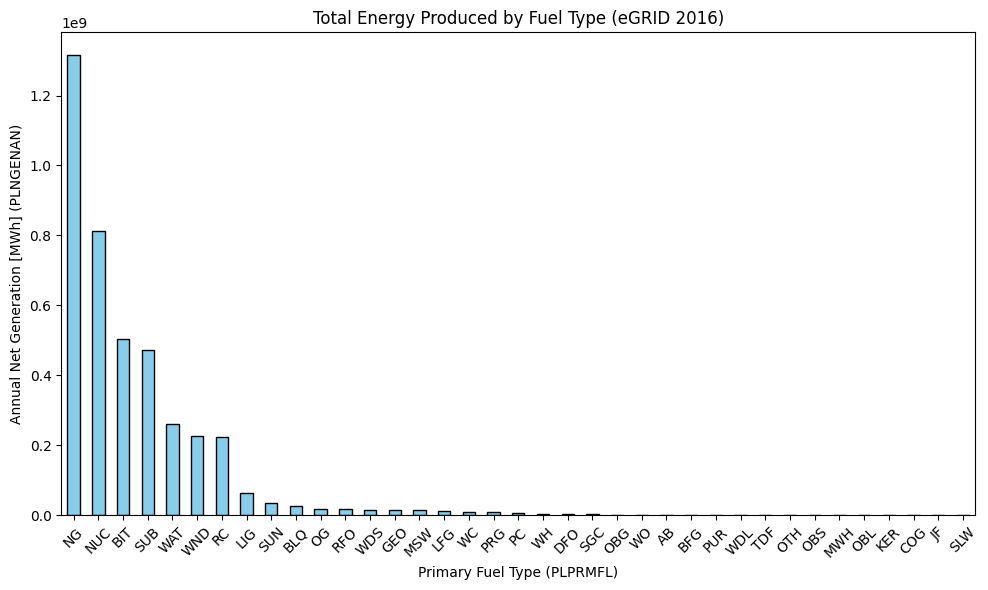

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_excel('a1_egrid2016.xlsx', header=1)
except FileNotFoundError:
    print("Error: 'a1_egrid2016.xlsx' not found. Please upload it to Colab.")

if 'df' in locals():
    max_energy_idx = df['PLNGENAN'].idxmax()
    print(f"(a)  {df.loc[max_energy_idx, 'PNAME']}")

    north_most_idx = df['LAT'].idxmax()
    print(f"(b)  {df.loc[north_most_idx, 'PNAME']}")
    print(f"(c)  {df.loc[north_most_idx, 'PSTATABB']}")

    fuel_energy = df.groupby('PLPRMFL')['PLNGENAN'].sum()
    print(f"(e)  {fuel_energy.idxmax()}")

    plt.figure(figsize=(10, 6))
    fuel_energy.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Total Energy Produced by Fuel Type (eGRID 2016)')
    plt.xlabel('Primary Fuel Type (PLPRMFL)')
    plt.ylabel('Annual Net Generation [MWh] (PLNGENAN)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8
**[6 points]** *Vectorization*. When we first learn to code and think about iterating over an array, we often use loops. If implemented correctly, that does the trick. In machine learning, we iterate over so much data that those loops can lead to significant slow downs if they are not computationally efficient. In Python, vectorizing code and relying on matrix operations with efficient tools like numpy is typically the faster approach. Of course, numpy relies on loops to complete the computation, but this is at a lower level of programming (typically in C), and therefore is much more efficient. This exercise will explore the benefits of vectorization. Since many machine learning techniques rely on matrix operations, it's helpful to begin thinking about implementing algorithms using vector forms.

Begin by creating an array of 1 million random numbers using the numpy `random.randn` module. Compute the sum of the squares of those random numbers first in a for loop, then using Numpy's `dot` module to perform an inner (dot) product. Time how long it takes to compute each and report the results and report the output. How many times faster is the vectorized code than the for loop approach? (Note - your results may vary from run to run).

Your output should use the `print()` function as follows (where the # symbols represent your answers, to a reasonable precision of 4-5 significant figures):

`Time [sec] (non-vectorized): ######`

`Time [sec] (vectorized):     ######`

`The vectorized code is ##### times faster than the nonvectorized code`

**ANSWER**

In [60]:
import numpy as np
import time

array = np.random.randn(1000000)

start_nonv = time.time()
sum_nonv = 0
for x in array:
    sum_nonv += x**2
time_nonv = time.time() - start_nonv

start_vec = time.time()
sum_vec = np.dot(array, array)
time_vec = time.time() - start_vec

print(f"Time [sec] (non-vectorized): {time_nonv:.4g}")
print(f"Time [sec] (vectorized): {time_vec:.4g}")
print(f"The vectorized code is {time_nonv/time_vec:.4g} times faster than the nonvectorized code")

Time [sec] (non-vectorized): 0.3281
Time [sec] (vectorized): 0.0009909
The vectorized code is 331.1 times faster than the nonvectorized code


## 9
**[10 points]** This exercise will walk through some basic numerical programming and probabilistic thinking exercises, two skills which are frequently use in machine learning for answering questions from our data.
1. Synthesize $n=10^4$ normally distributed data points with mean $\mu=2$ and a standard deviation of $\sigma=1$. Call these observations from a random variable $X$, and call the vector of observations that you generate, $\textbf{x}$.
2. Calculate the mean and standard deviation of $\textbf{x}$ to validate (1) and provide the result to a precision of four significant figures.
3. Plot a histogram of the data in $\textbf{x}$ with 30 bins
4. What is the 90th percentile of $\textbf{x}$? The 90th percentile is the value below which 90% of observations can be found.
5. What is the 99th percentile of $\textbf{x}$?
6. Now synthesize $n=10^4$ normally distributed data points with mean $\mu=0$ and a standard deviation of $\sigma=3$. Call these observations from a random variable $Y$, and call the vector of observations that you generate, $\textbf{y}$.
7. Create a new figure and plot the histogram of the data in $\textbf{y}$ on the same axes with the histogram of $\textbf{x}$, so that both histograms can be seen and compared.
8. Using the observations from $\textbf{x}$ and $\textbf{y}$, estimate $E[XY]$

**ANSWER**

Mean of x: 1.999
Standard deviation of x: 0.9971


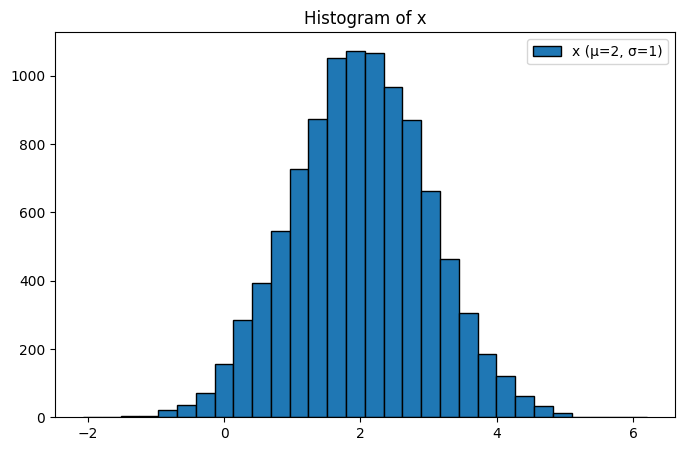

90th percentile of x: 3.256
99th percentile of x: 4.299


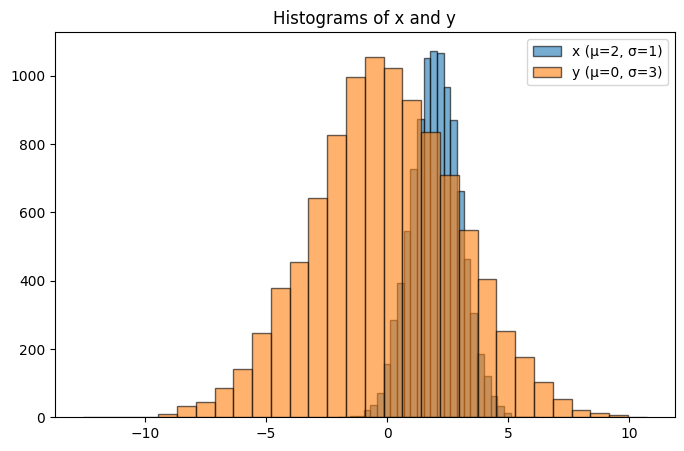

Estimated E[XY]: -0.08538


In [61]:
import numpy as np
import matplotlib.pyplot as plt

n=10**4
x=np.random.normal(2, 1, n)

mean_x=np.mean(x)
std_x=np.std(x)
print(f"Mean of x: {mean_x:.4g}")
print(f"Standard deviation of x: {std_x:.4g}")

plt.figure(figsize=(8, 5))
plt.hist(x, bins=30, edgecolor='black',label='x (μ=2, σ=1)')
plt.legend()
plt.title("Histogram of x")
plt.show()

p90_x=np.percentile(x, 90)
p99_x=np.percentile(x, 99)
print(f"90th percentile of x: {p90_x:.4g}")
print(f"99th percentile of x: {p99_x:.4g}")

y = np.random.normal(0, 3, n)

plt.figure(figsize=(8, 5))
plt.hist(x, bins=30, alpha=0.6, edgecolor='black', label='x (μ=2, σ=1)')
plt.hist(y, bins=30, alpha=0.6, edgecolor='black', label='y (μ=0, σ=3)')
plt.legend()
plt.title("Histograms of x and y")
plt.show()

e_xy=np.mean(x * y)
print(f"Estimated E[XY]: {e_xy:.4g}")

# Version Control via Git

## 10
**[4 points]** Git is efficient for collaboration, and expectation in industry, and one of the best ways to share results in academia. You can even use some Git repositories (e.g. Github) as hosts for website, such as with the [course website](https://kylebradbury.github.io/ids705_sp2022/index.html). As a data scientist with experience in machine learning, Git is expected. We will interact with Git repositories (a.k.a. repos) throughout this course, and your project will require the use of git repos for collaboration.

Complete the [Atlassian Git tutorial](https://www.atlassian.com/git/tutorials/what-is-version-control), specifically the following listed sections. Try each concept that's presented. For this tutorial, instead of using BitBucket as your remote repository host, you may use your preferred platform such as [Github](https://github.com/) or [Duke's Gitlab](https://gitlab.oit.duke.edu/users/sign_in).
1. [What is version control](https://www.atlassian.com/git/tutorials/what-is-version-control)
2. [What is Git](https://www.atlassian.com/git/tutorials/what-is-git)
3. [Install Git](https://www.atlassian.com/git/tutorials/install-git)
4. [Setting up a repository](https://www.atlassian.com/git/tutorials/install-git)
5. [Saving changes](https://www.atlassian.com/git/tutorials/saving-changes)
6. [Inspecting a repository](https://www.atlassian.com/git/tutorials/inspecting-a-repository)
7. [Undoing changes](https://www.atlassian.com/git/tutorials/undoing-changes)
8. [Rewriting history](https://www.atlassian.com/git/tutorials/rewriting-history)
9. [Syncing](https://www.atlassian.com/git/tutorials/syncing)
10. [Making a pull request](https://www.atlassian.com/git/tutorials/making-a-pull-request)
11. [Using branches](https://www.atlassian.com/git/tutorials/using-branches)
12. [Comparing workflows](https://www.atlassian.com/git/tutorials/comparing-workflows)

I also have created two videos on the topic to help you understand some of these concepts: [Git basics](https://www.youtube.com/watch?v=fBCwfoBr2ng) and a [step-by-step tutorial](https://www.youtube.com/watch?v=nH7qJHx-h5s).

For your answer, affirm that you *either* completed the tutorials above OR have previous experience with ALL of the concepts above. Confirm this by typing your name below and selecting the situation that applies from the two options in brackets.

**ANSWER**

*I, [** Maiko Atsumi **], affirm that I have [**completed the above tutorial **]*

# Exploratory Data Analysis
## 11
**[20 points]** Here you'll bring together some of the individual skills that you demonstrated above and create a Jupyter notebook based blog post on your exploratory data analysis. Your goal is to identify a question or problem and to work towards solving it or providing additional information or evidence (data) related to it through your data analysis. Below, we walk through a process to follow for your analysis. Additionally, you can find an [example of a well-done exploratory data analysis here from past years](https://github.com/kylebradbury/ids705_sp2022/blob/master/assignments/Assignment_1_Q11_Example.ipynb).

1. Find a dataset that interests you and relates to a question or problem that you find intriguing.
2. Describe the dataset, the source of the data, and the reason the dataset was of interest. What question are you hoping to answer through exploring the dataset?
3. Check the data and see if they need to be cleaned: are there missing values? Are there clearly erroneous values? Do two tables need to be merged together? Clean the data so it can be visualized. If the data are clean, state how you know they are clean (what did you check?).
3. Plot the data, demonstrating interesting features that you discover. Are there any relationships between variables that were surprising or patterns that emerged? Please exercise creativity and curiosity in your plots. You should have at least a ~3 plots exploring the data in different ways.
4. What insights are you able to take away from exploring the data? Is there a reason why analyzing the dataset you chose is particularly interesting or important? Summarize this for a general audience (imagine your publishing a blog post online) - boil down your findings in a way that is accessible, but still accurate.

Here your analysis will evaluated based on:
1. Motivation: was the purpose of the choice of data clearly articulated? Why was the dataset chosen and what was the goal of the analysis?
2. Data cleaning: were any issues with the data investigated and, if found, were they resolved?
3. Quality of data exploration: were at least 4 unique plots (minimum) included and did those plots demonstrate interesting aspects of the data? Was there a clear purpose and takeaway from EACH plot?
4. Interpretation: Were the insights revealed through the analysis and their potential implications clearly explained? Was there an overall conclusion to the analysis?

**ANSWER**


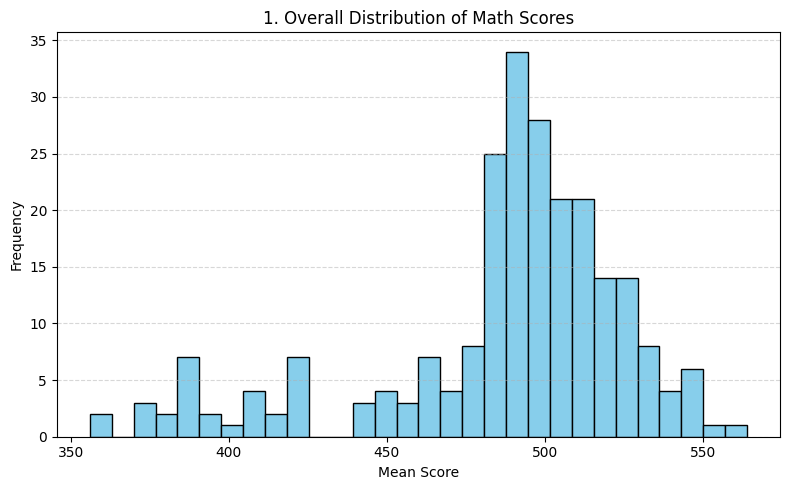

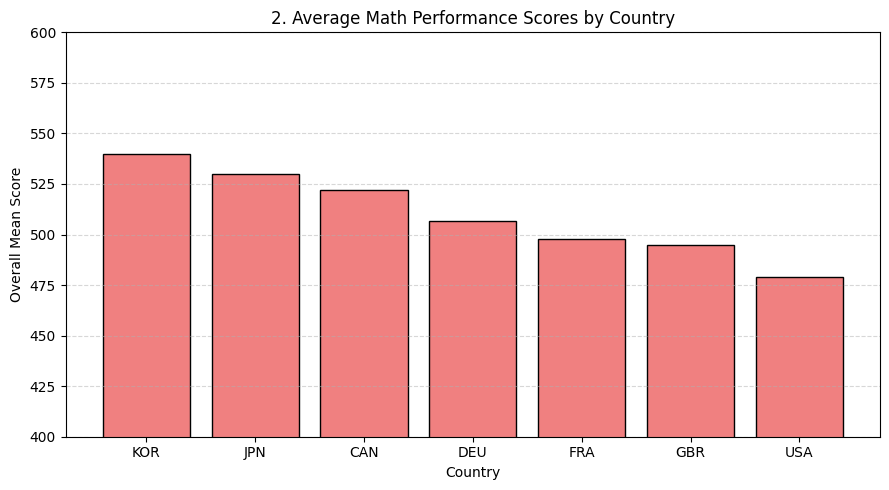

Score Stability Statistics by Country:
LOCATION       mean        var       std
     GBR 495.000000  17.000000  4.123106
     JPN 530.166667  22.966667  4.792355
     DEU 506.666667  31.866667  5.645057
     USA 478.833333  38.166667  6.177918
     FRA 497.833333  43.366667  6.585337
     CAN 522.000000  60.400000  7.771744
     KOR 539.833333 147.366667 12.139467


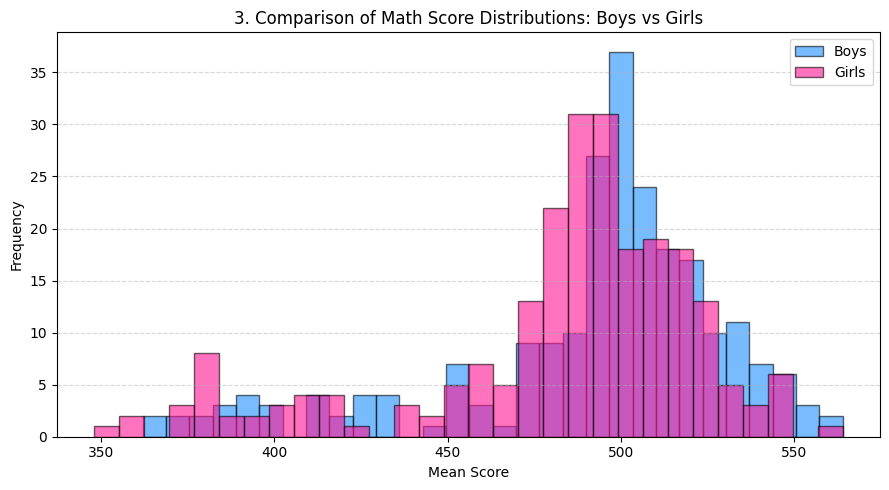

         Group       Mean         Var       Std
 Boys (Global) 491.511651 1696.402788 41.187411
Girls (Global) 482.384310 1758.398155 41.933258


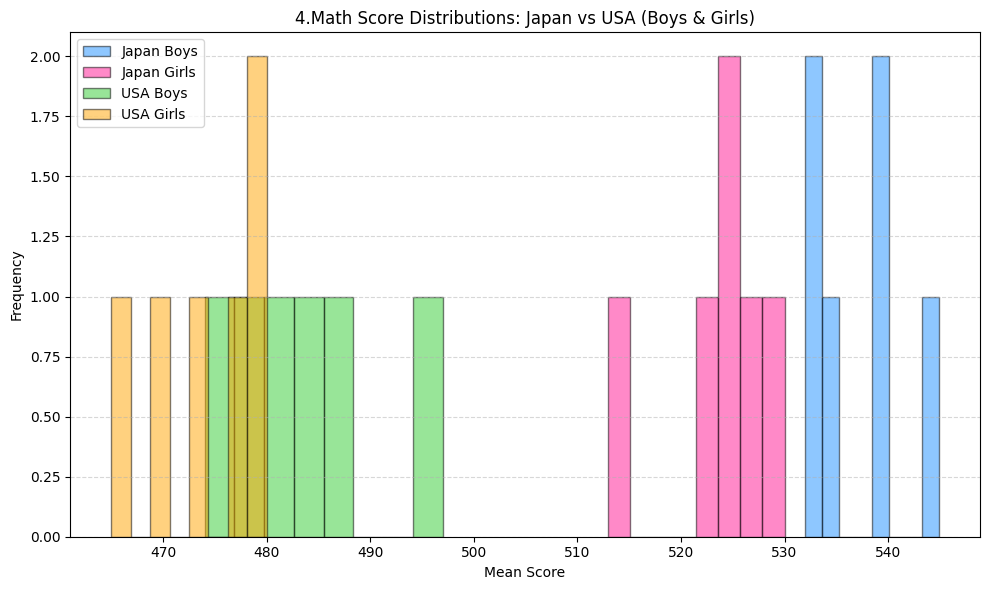

      Group       Mean       Var      Std
 Japan Boys 536.980667 24.031043 4.902147
Japan Girls 523.501833 33.915420 5.823695
   USA Boys 483.607833 60.240368 7.761467
  USA Girls 474.165833 33.357004 5.775552


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('OECD PISA data.csv')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

#figuer1
math_tot = df[(df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'TOT')]

plt.figure(figsize=(8, 5))
plt.hist(math_tot['Value'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('1. Overall Distribution of Math Scores')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#figuer2
target_countries = ['JPN', 'USA', 'CAN', 'GBR', 'DEU', 'FRA', 'KOR']
mean_by_country = math_tot[math_tot['LOCATION'].isin(target_countries)].groupby('LOCATION')['Value'].mean().reset_index()
mean_by_country = mean_by_country.sort_values(by='Value', ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(mean_by_country['LOCATION'], mean_by_country['Value'], color='lightcoral', edgecolor='black')
plt.title('2. Average Math Performance Scores by Country')
plt.xlabel('Country')
plt.ylabel('Overall Mean Score')
plt.ylim(400, 600)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

stability_stats = math_tot[math_tot['LOCATION'].isin(target_countries)].groupby('LOCATION')['Value'].agg(mean='mean', var='var',std='std').reset_index()
stability_stats = stability_stats.sort_values(by='std', ascending=True)

print("Score Stability Statistics by Country:")
print(stability_stats.to_string(index=False))

#figure3
math_boys = df[(df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'BOY')]['Value'].dropna()
math_girls = df[(df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'GIRL')]['Value'].dropna()

fig3_stats = {
    'Group': ['Boys (Global)', 'Girls (Global)'],
    'Mean': [math_boys.mean(), math_girls.mean()],
    'Var': [math_boys.var(), math_girls.var()],
    'Std': [math_boys.std(), math_girls.std()]
}
fig3_df = pd.DataFrame(fig3_stats)

plt.figure(figsize=(9, 5))
plt.hist(math_boys, bins=30, alpha=0.6, color='dodgerblue', edgecolor='black', label='Boys')
plt.hist(math_girls, bins=30, alpha=0.6, color='deeppink', edgecolor='black', label='Girls')
plt.title('3. Comparison of Math Score Distributions: Boys vs Girls')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(fig3_df.to_string(index=False))

#figure4
jp_boys = df[(df['LOCATION'] == 'JPN') & (df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'BOY')]['Value'].dropna()
jp_girls = df[(df['LOCATION'] == 'JPN') & (df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'GIRL')]['Value'].dropna()
usa_boys = df[(df['LOCATION'] == 'USA') & (df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'BOY')]['Value'].dropna()
usa_girls = df[(df['LOCATION'] == 'USA') & (df['INDICATOR'] == 'PISAMATH') & (df['SUBJECT'] == 'GIRL')]['Value'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(jp_boys, bins=8, alpha=0.5, color='dodgerblue', edgecolor='black', label='Japan Boys')
plt.hist(jp_girls, bins=8, alpha=0.5, color='deeppink', edgecolor='black', label='Japan Girls')
plt.hist(usa_boys, bins=8, alpha=0.5, color='limegreen', edgecolor='black', label='USA Boys')
plt.hist(usa_girls, bins=8, alpha=0.5, color='orange', edgecolor='black', label='USA Girls')
plt.title('4.Math Score Distributions: Japan vs USA (Boys & Girls)')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

stats_data = {
    'Group': ['Japan Boys', 'Japan Girls', 'USA Boys', 'USA Girls'],
    'Mean': [jp_boys.mean(), jp_girls.mean(), usa_boys.mean(), usa_girls.mean()],
    'Var': [jp_boys.var(), jp_girls.var(), usa_boys.var(), usa_girls.var()],
    'Std': [jp_boys.std(), jp_girls.std(), usa_boys.std(), usa_girls.std()]
}
stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

## Analysis & Interpretation

## 1. Motivation and Overview
As an international student navigating different educational environments, understanding how academic performance is distributed across countries provides vital insights into global educational trends. This exploratory data analysis (EDA) investigates the OECD Programme for International Student Assessment (PISA) dataset, focusing on mathematics performance scores from 2000 to 2018 across multiple nations, with a primary comparison between Japan and the United States. The goal is to uncover structural patterns in national performance, longitudinal score stability, and gender disparities in mathematical literacy.

## 2. Data Cleaning & Preparation
The raw dataset (`OECD PISA data.csv`) was loaded and preprocessed using Python and Pandas. The `Value` column, which contains the mean performance scores, was cleaned by coercing invalid or missing entries into standard numeric types (`NaN`). Rows with missing values were handled appropriately during aggregation.

## 3. Exploratory Data Analysis & Visualizations
The analysis incorporates four distinct visualization approaches to examine the data from multiple angles:
* **Overall Distribution (Histogram):** Captures the global spread of mean math scores across all countries and years, revealing an approximate bell-shaped curve centered around OECD benchmarks.
* **Country-Level Comparison (Bar Plot):** Visualizes the overall mean math performance across selected industrialized nations (Japan, USA, Canada, UK, Germany, France, South Korea) with a truncated y-axis ($400$ to $600$) to clearly highlight relative differences.
* **Global Gender Comparison (Overlaid Histogram):** Compares the distribution of math performance between all male and female student cohorts worldwide.
* **Bivariate Gender-Country Distribution (Multi-Group Histogram):** Breaks down performance into four distinct cohorts—Japanese Boys, Japanese Girls, USA Boys, and USA Girls—treating annual observations as sample points to evaluate distributional shifts.

## 4. Limitations of the Dataset
While the PISA dataset offers robust cross-national benchmarks, several methodological limitations must be acknowledged:
* **Level of Aggregation:** The dataset provides *national mean scores per cycle/year* rather than individual student-level data. Consequently, calculating the variance and standard deviation of these values captures **inter-year (longitudinal) variance** rather than **intra-country individual-level variance** among students.
* **Small Sample Size for Dispersion Metrics:** Because PISA evaluations occur roughly every three years (resulting in approximately 6 data points per country-gender subgroup within the 2000–2018 window), the sample size ($N \approx 6$) is quite small. While sufficient for tracking general trends, this limited number of temporal observations makes variance and standard deviation calculations statistically sensitive and less reliable for precise dispersion analysis.

##5. Key Insights & ConclusionGlobal
Performance Spread (Figure 1): The overall distribution of mean math scores across all countries and years forms an approximately bell-shaped curve centered around OECD benchmarks, illustrating typical international performance variations.Cross-National Performance Levels (Figure 2): When comparing selected industrialized nations using a truncated scale ($400$ to $600$), Japan consistently achieves a higher overall mean score than the United States, reflecting structural differences in educational achievement.Global Gender Patterns (Figure 3): Across the wider global dataset, the overlaid histograms for male and female student cohorts show largely comparable distributional shapes, though minor shifts appear in aggregate averages.Bivariate Cohort Comparison (Figure 4): Breaking down the data into four specific groups—Japan Boys, Japan Girls, USA Boys, and USA Girls—highlights both the performance gap between nations and the internal consistency within gender cohorts. Specifically, Japanese male and female cohorts cluster at higher score ranges (means of $536.98$ and $523.50$, respectively) compared to their U.S. counterparts ($483.61$ and $474.17$). Furthermore, the calculated variance and standard deviation values across survey years show that Japan maintains tighter longitudinal stability (lower variance), whereas the United States experiences wider temporal fluctuations (higher variance, particularly among male cohorts).Ultimately, while aggregate international datasets provide valuable macro-level insights for global educational comparison, researchers must account for structural constraints such as temporal aggregation and limited sample sizes when evaluating statistical metrics.

**AI Usage**:

 AI tools were utilized to assist with debugging code errors, translating conceptual explanations into natural English phrasing, and checking English grammar and sentence structure.